In [1]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import uxarray as ux
import parcels
from uxarray.constants import INT_FILL_VALUE

/tmp/ipykernel_485151/156823637.py:6: UserWarning: This is an alpha version of Parcels v4. The API is not stable and may change without deprecation warnings.
  import parcels


In [2]:
# no2d = xr.open_dataset('/work/bk1450/b383184/ELPHE_hackathon/Double_gyre/FESOM_v2.7/1d/unod.fesom.1950.nc')
# no2d

mesh = xr.open_dataset('/work/bk1450/b383184/ELPHE_hackathon/Double_gyre/FESOM_v2.7/1d/fesom.mesh.diag.nc')
mesh

<xarray.Dataset> Size: 33MB
Dimensions:            (elem: 73702, nod2: 37239, nz: 41, n3: 3, n2: 2,
                        edg_n: 110940, N: 6, n4: 4, nz1: 40)
Coordinates:
  * nz                 (nz) float64 328B 0.0 9.038 18.98 ... 3.628e+03 4e+03
  * nz1                (nz1) float64 320B 4.519 14.01 ... 3.459e+03 3.814e+03
Dimensions without coordinates: elem, nod2, n3, n2, edg_n, N, n4
Data variables: (12/23)
    fesom_mesh         int32 4B ...
    elem_area          (elem) float64 590kB ...
    nlevels_nod2D      (nod2) int32 149kB ...
    nlevels            (elem) int32 295kB ...
    nod_in_elem2D_num  (nod2) int32 149kB ...
    nod_part           (nod2) int32 149kB ...
    ...                 ...
    nod_in_elem2D      (N, nod2) int32 894kB ...
    edge_cross_dxdy    (n4, edg_n) float64 4MB ...
    gradient_sca_x     (n3, elem) float64 2MB ...
    gradient_sca_y     (n3, elem) float64 2MB ...
    gradient_vec_x     (n3, elem) float64 2MB ...
    gradient_vec_y     (n3, elem) float64 2MB ...
Attributes:
    Conventions:  UGRID-1.0

In [3]:
grid_path = "/work/bk1450/b383184/ELPHE_hackathon/Double_gyre/FESOM_v2.7/1d/fesom.mesh.diag.nc"

data_paths = [
    "/work/bk1450/b383184/ELPHE_hackathon/FESOM_1d/u.fesom.1950.nc",
    "/work/bk1450/b383184/ELPHE_hackathon/FESOM_1d/v.fesom.1950.nc",
    "/work/bk1450/b383184/ELPHE_hackathon/FESOM_1d/w.fesom.1950.nc",
]

ds = ux.open_mfdataset(grid_path, data_paths).compute()
ds

<xarray.UxDataset> Size: 11GB
Dimensions:  (nz1: 40, time: 365, n_face: 73702, nz: 41, n_node: 37239)
Coordinates:
  * nz1      (nz1) float64 320B 4.519 14.01 24.45 ... 3.459e+03 3.814e+03
  * time     (time) datetime64[ns] 3kB 1950-01-01T23:50:00 ... 1950-12-31T23:...
  * nz       (nz) float64 328B 0.0 9.038 18.98 ... 3.29e+03 3.628e+03 4e+03
Dimensions without coordinates: n_face, n_node
Data variables:
    u        (time, nz1, n_face) float32 4GB 0.08384 -0.1518 ... -0.001951
    v        (time, nz1, n_face) float32 4GB 0.2584 0.1794 ... -0.003294
    w        (time, nz, n_node) float32 2GB -3.778e-08 -3.747e-08 ... nan nan
Attributes: (12/18)
    title:                               FESOM2 output
    FESOM_model:                         FESOM2
    FESOM_website:                       fesom.de
    FESOM_git_SHA:                       9aa93f20
    FESOM_MeshPath:                      /gxfs_work/geomar/smomw018/INPUT/FES...
    FESOM_mesh_representative_checksum:  
    ...                                  ...
    FESOM_use_floatice:                  0
    FESOM_whichEVP:                      0
    FESOM_evp_rheol_steps:               120
    FESOM_opt_visc:                      5
    FESOM_use_wsplit:                    0
    FESOM_autorotate_back_to_geo:        0

In [4]:
((ds.v.isel(time=0,nz1=0)**2 + ds.u.isel(time=0,nz1=0)**2)**0.5).plot()

:Image   [x,y]   (x_y var)

In [5]:
ds = ds.rename_vars({"u": "U", "v": "V", "w":"W"})
ds

<xarray.UxDataset> Size: 11GB
Dimensions:  (nz1: 40, time: 365, n_face: 73702, nz: 41, n_node: 37239)
Coordinates:
  * nz1      (nz1) float64 320B 4.519 14.01 24.45 ... 3.459e+03 3.814e+03
  * time     (time) datetime64[ns] 3kB 1950-01-01T23:50:00 ... 1950-12-31T23:...
  * nz       (nz) float64 328B 0.0 9.038 18.98 ... 3.29e+03 3.628e+03 4e+03
Dimensions without coordinates: n_face, n_node
Data variables:
    U        (time, nz1, n_face) float32 4GB 0.08384 -0.1518 ... -0.001951
    V        (time, nz1, n_face) float32 4GB 0.2584 0.1794 ... -0.003294
    W        (time, nz, n_node) float32 2GB -3.778e-08 -3.747e-08 ... nan nan
Attributes: (12/18)
    title:                               FESOM2 output
    FESOM_model:                         FESOM2
    FESOM_website:                       fesom.de
    FESOM_git_SHA:                       9aa93f20
    FESOM_MeshPath:                      /gxfs_work/geomar/smomw018/INPUT/FES...
    FESOM_mesh_representative_checksum:  
    ...                                  ...
    FESOM_use_floatice:                  0
    FESOM_whichEVP:                      0
    FESOM_evp_rheol_steps:               120
    FESOM_opt_visc:                      5
    FESOM_use_wsplit:                    0
    FESOM_autorotate_back_to_geo:        0

In [6]:
ds = parcels.convert.fesom_to_ugrid(ds)
print("dims:", dict(ds.sizes))


INFO: Using known vertical dimension mapping: 'nz' (interfaces) and 'nz1' (centers).
INFO: Renaming vertical dimensions: {'nz': 'zf', 'nz1': 'zc'}
dims: {'zc': 40, 'time': 365, 'n_face': 73702, 'zf': 41, 'n_node': 37239}


In [7]:
fieldset = parcels.FieldSet.from_ugrid_conventions(ds, mesh="spherical")

for name, field in fieldset.fields.items():
    interp = getattr(field, "interp_method", None)
    interp_name = interp.__name__ if interp is not None else "-"
    print(f"{name:>4s}  ->  {type(field).__name__:<11s}  interp={interp_name}")

   U  ->  Field        interp=UxConstantFaceConstantZC
   V  ->  Field        interp=UxConstantFaceConstantZC
  UV  ->  VectorField  interp=-
   W  ->  Field        interp=UxLinearNodeLinearZF
 UVW  ->  VectorField  interp=-


In [8]:
# Cell-view linear least-squares reconstruction for face-registered, layer-centered data.
def LinearFaceRecon(particle_positions, grid_positions, field):
    ti = grid_positions["T"]["index"]
    zi = grid_positions["Z"]["index"]
    fi = grid_positions["FACE"]["index"]

    uxg = field.grid.uxgrid
    gx = uxg._ds["gradient_coeff_x"].values[fi]  # (M, K)
    gy = uxg._ds["gradient_coeff_y"].values[fi]
    nb = uxg._ds["recon_face_neighbors"].values[fi]  # (M, K)
    mask = uxg._ds["recon_neighbor_mask"].values[fi]

    uc = field.data.values[ti, zi, fi]  # (M,)
    un = field.data.values[ti[:, None], zi[:, None], nb]  # (M, K)
    du = (un - uc[:, None]) * mask
    ax = np.sum(gx * du, axis=1)
    ay = np.sum(gy * du, axis=1)

    flon = uxg.face_lon.values[fi]
    flat = uxg.face_lat.values[fi]
    dx, dy = local_offsets(
        field.grid._mesh,
        flon,
        flat,
        particle_positions["lon"],
        particle_positions["lat"],
    )
    return uc + ax * dx + ay * dy

In [9]:
DEG2M = 1852.0 * 60.0  # metres per degree (matches Ux_Velocity unit conversion)


def local_offsets(mesh, lon_c, lat_c, lon, lat):
    # local planar offset (dx, dy) of (lon, lat) from centroid (lon_c, lat_c)
    if mesh == "spherical":
        dlon = ((np.asarray(lon) - lon_c + 180.0) % 360.0) - 180.0
        dx = dlon * np.cos(np.deg2rad(lat_c)) * DEG2M
        dy = (np.asarray(lat) - lat_c) * DEG2M
    else:  # flat mesh: coordinates are already a planar (x, y)
        dx = np.asarray(lon) - lon_c
        dy = np.asarray(lat) - lat_c
    return dx, dy


# Compute and attach cell-view least-squares gradient coefficients. Adds to
# uxgrid._ds: gradient_coeff_x/_y, recon_face_neighbors (fill -> self),
# recon_neighbor_mask (1.0 valid / 0.0 absent), all (n_face, n_max_face_faces).
def build_reconstruction_terms(uxgrid, mesh):
    nbr = np.asarray(uxgrid.face_face_connectivity.values)  # (F, K)
    flon = np.asarray(uxgrid.face_lon.values)
    flat = np.asarray(uxgrid.face_lat.values)

    valid = nbr != INT_FILL_VALUE
    nbr_safe = np.where(valid, nbr, 0)

    dx, dy = local_offsets(
        mesh, flon[:, None], flat[:, None], flon[nbr_safe], flat[nbr_safe]
    )
    dx = np.where(valid, dx, 0.0)  # absent -> no contribution
    dy = np.where(valid, dy, 0.0)

    X2 = np.sum(dx * dx, axis=1)
    Y2 = np.sum(dy * dy, axis=1)
    XY = np.sum(dx * dy, axis=1)
    d = X2 * Y2 - XY * XY

    # cells with < 2 independent neighbours give d == 0 -> flat (zero-gradient)
    # fallback, i.e. the original piecewise-constant value.
    ok = d != 0.0
    inv_d = np.where(ok, 1.0 / np.where(ok, d, 1.0), 0.0)

    gx = (dx * Y2[:, None] - dy * XY[:, None]) * inv_d[:, None]
    gy = (dy * X2[:, None] - dx * XY[:, None]) * inv_d[:, None]
    gx = np.where(valid, gx, 0.0)
    gy = np.where(valid, gy, 0.0)

    dims = ("n_face", "n_max_face_faces")
    uxgrid._ds["gradient_coeff_x"] = xr.DataArray(gx, dims=dims)
    uxgrid._ds["gradient_coeff_y"] = xr.DataArray(gy, dims=dims)
    uxgrid._ds["recon_face_neighbors"] = xr.DataArray(nbr_safe, dims=dims)
    uxgrid._ds["recon_neighbor_mask"] = xr.DataArray(
        valid.astype(np.float64), dims=dims
    )
    return uxgrid

In [10]:
# attach the metric terms to the grid shared by the fields
uxgrid = fieldset.fields["U"].grid.uxgrid
build_reconstruction_terms(uxgrid, mesh="spherical")
print("default T_face interpolator:", fieldset.fields["U"].interp_method.__name__)
print(
    "stored on uxgrid._ds:",
    [v for v in uxgrid._ds.data_vars if v.startswith(("gradient", "recon"))],
)

default T_face interpolator: UxConstantFaceConstantZC
stored on uxgrid._ds: ['gradient_sca_x', 'gradient_sca_y', 'gradient_vec_x', 'gradient_vec_y', 'gradient_coeff_x', 'gradient_coeff_y', 'recon_face_neighbors', 'recon_neighbor_mask']


In [11]:
fieldset.fields['U'].interp_method = LinearFaceRecon
fieldset.fields['V'].interp_method = LinearFaceRecon

In [12]:
lon_grid, lat_grid = np.meshgrid(
        np.linspace(8., 11., 10), np.linspace(32., 33., 10)
    )

In [13]:
lon_grid.shape
z=np.full(lon_grid.size, 10.0)
z

array([10., 10., 10., 10., 10., 10., 10., 10., 10., 10., 10., 10., 10.,
       10., 10., 10., 10., 10., 10., 10., 10., 10., 10., 10., 10., 10.,
       10., 10., 10., 10., 10., 10., 10., 10., 10., 10., 10., 10., 10.,
       10., 10., 10., 10., 10., 10., 10., 10., 10., 10., 10., 10., 10.,
       10., 10., 10., 10., 10., 10., 10., 10., 10., 10., 10., 10., 10.,
       10., 10., 10., 10., 10., 10., 10., 10., 10., 10., 10., 10., 10.,
       10., 10., 10., 10., 10., 10., 10., 10., 10., 10., 10., 10., 10.,
       10., 10., 10., 10., 10., 10., 10., 10., 10.])

In [14]:
def run_fesom(label):
    # fesom.fields["U"].interp_method = interp
    # fesom.fields["V"].interp_method = interp
    lon_grid, lat_grid = np.meshgrid(
        np.linspace(8., 11., 10), np.linspace(32., 33., 10)
    )
    pset = parcels.ParticleSet(
        fieldset,
        pclass=parcels.Particle,
        lon=lon_grid.ravel(),
        lat=lat_grid.ravel(),
        z=np.full(lon_grid.size, 50.0),
    )
    out = parcels.ParticleFile(
        f"recon-{label}.parquet", outputdt=np.timedelta64(1, "h"), mode="w",
    )
    pset.execute(
        [parcels.kernels.AdvectionRK4],
        runtime=np.timedelta64(2, "D"),
        dt=np.timedelta64(5, "m"),
        output_file=out,
        verbose_progress=True,
    )
    return parcels.read_particlefile(f"recon-{label}.parquet")


df_const = run_fesom("LinearFaceRecon")
# df_lin = run_fesom("linear")
print("advection done")

INFO: Output files are stored in recon-LinearFaceRecon.parquet
Integration time: 1950-01-03T22:50:00 100%|██████████| [00:04<00:00, 38015.09it/s]
advection done


In [15]:
df_const

lon,lat,z,time,particle_id
f32,f32,f32,datetime[ns],i64
8.0,32.0,50.0,1950-01-01 23:50:00,0
8.333333,32.0,50.0,1950-01-01 23:50:00,1
8.666667,32.0,50.0,1950-01-01 23:50:00,2
9.0,32.0,50.0,1950-01-01 23:50:00,3
9.333333,32.0,50.0,1950-01-01 23:50:00,4
…,…,…,…,…
10.65428,33.271313,50.0,1950-01-03 23:50:00,95
10.775173,33.236412,50.0,1950-01-03 23:50:00,96
10.95883,33.271317,50.0,1950-01-03 23:50:00,97


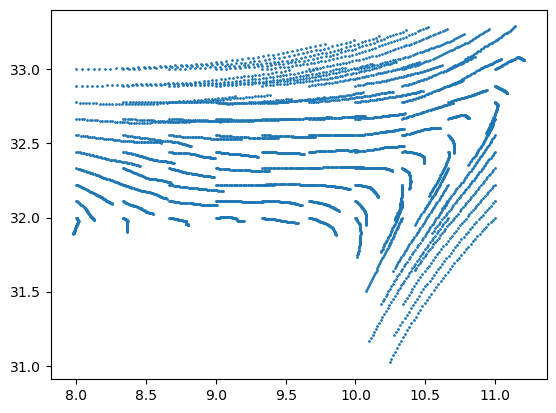

In [16]:
import matplotlib.pyplot as plt

plt.scatter(df_const['lon'].to_numpy(),df_const['lat'].to_numpy(),1)
# df_const['lon'].to_numpy(